# 01 认识数据与 Tensor：先看懂形状，再进入 MLP

这一节不训练模型，只解决一个基础问题：**数据进入神经网络前，到底长什么样？**

完成后，你应该能够：

- 用自己的话解释 Tensor；
- 看懂 `shape`、`ndim`、`dtype` 和 `device`；
- 使用索引取出一个数、一行或一列；
- 区分“一个样本”和“一个 mini-batch”；
- 看懂二维点、28×28 灰度图以及 MLP 输入的形状。

> 本 Notebook 只使用 **CPU**，不会占用共享服务器的 GPU。

## 1. 先建立最朴素的直觉

Tensor 可以先理解为：**把若干个数按规则摆放在一起的容器**。

Python 列表也能保存一组数，但 Tensor 还记录了数据的形状、类型和所在设备，并且支持神经网络需要的批量计算与自动求导。

在 PyTorch 中：

- `torch.Tensor` 是 Tensor 类型；
- `torch.tensor(...)` 是根据已有数据创建 Tensor 的常用函数。

这一节的顺序参考 PyTorch 官方入门教程：[Tensors](https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html)。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

notebook_dir = Path.cwd()
if not (notebook_dir / "mlp_lab").exists():
    notebook_dir = notebook_dir / "01_mlp_lab"
sys.path.insert(0, str(notebook_dir))

import matplotlib.pyplot as plt
import torch

from mlp_lab import make_dataset
from mlp_lab.plots import configure_chinese_font
from tensor_visuals import (
    plot_image_tensor_shapes,
    plot_mlp_shape_flow,
    plot_moons_tensor_map,
    plot_sample_to_batch,
    plot_tensor_dimensions,
    plot_tensor_indexing,
)

torch.manual_seed(42)
font_name = configure_chinese_font()
print("PyTorch 版本：", torch.__version__)
print("中文字体：", font_name)
print("本节计算设备：CPU")

PyTorch 版本： 2.11.0+cu128
中文字体： Noto Sans CJK SC
本节计算设备：CPU


### 1.1 同一组数字：列表与 Tensor

下面两个对象装着相同的数。先观察它们的类型与形状。

In [2]:
number_list = [[1.0, 2.0, 3.0],
               [4.0, 5.0, 6.0]]
x = torch.tensor(number_list, dtype=torch.float32)

print("Python 列表：", number_list)
print("Tensor：\n", x)
print("类型：", type(x))
print("shape：", x.shape)

Python 列表： [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]
Tensor：
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
类型： <class 'torch.Tensor'>
shape： torch.Size([2, 3])


### 1.2 官方教程中最常见的创建方式

- `torch.tensor`：使用已经知道的数值；
- `torch.zeros`：创建全 0 Tensor；
- `torch.ones`：创建全 1 Tensor；
- `torch.rand`：创建 0 到 1 之间的随机数 Tensor。

先关注共同点：下面每个结果都有 **2 行、3 列**。

In [3]:
examples = {
    "指定数值": torch.tensor([[1, 2, 3], [4, 5, 6]]),
    "全 0": torch.zeros(2, 3),
    "全 1": torch.ones(2, 3),
    "随机数": torch.rand(2, 3),
}

for name, value in examples.items():
    print(f"{name:4s}  shape={tuple(value.shape)}  dtype={value.dtype}")
    print(value, "\n")

指定数值  shape=(2, 3)  dtype=torch.int64
tensor([[1, 2, 3],
        [4, 5, 6]]) 

全 0   shape=(2, 3)  dtype=torch.float32
tensor([[0., 0., 0.],
        [0., 0., 0.]]) 

全 1   shape=(2, 3)  dtype=torch.float32
tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

随机数   shape=(2, 3)  dtype=torch.float32
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]]) 



## 2. 维度（ndim）与形状（shape）

- **维度 ndim**：定位一个数需要几个索引；
- **形状 shape**：每个轴分别有多长。

例如，一个形状为 `(2, 3)` 的 Tensor 有两个轴：第 0 轴长度为 2，第 1 轴长度为 3，因此它是二维 Tensor。

> 这里的“维度”是 Tensor 的轴数，不是线性代数中矩阵的秩（rank）。三维、四维 Tensor 也不必真的长成立方体；图形只是帮助理解数据的组织层次。

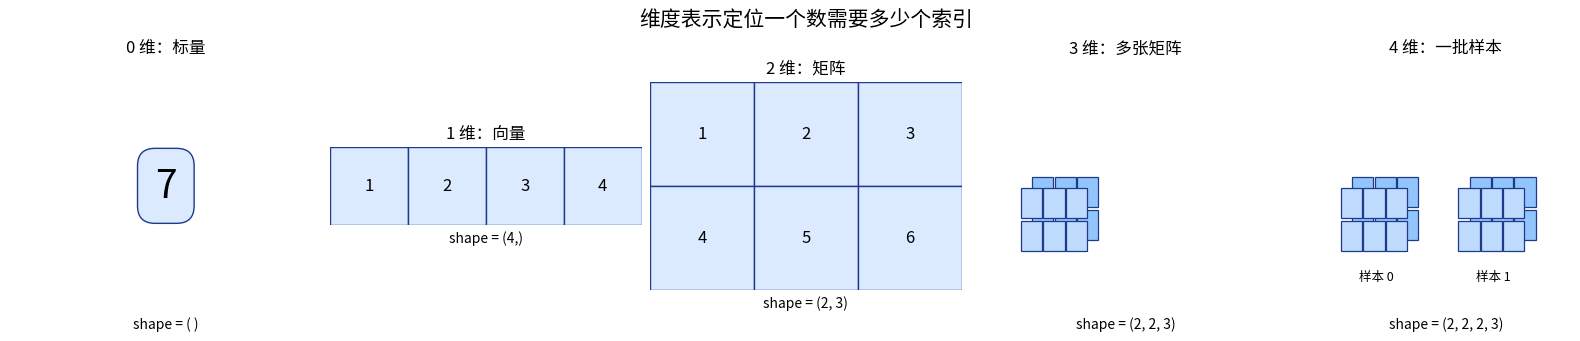

In [4]:
figure = plot_tensor_dimensions()
plt.show()

### 2.1 Tensor 的四张“身份证”

以后拿到一个陌生 Tensor，先查看：

- `shape`：各轴长度；
- `ndim`：轴的数量；
- `dtype`：每个数的数据类型；
- `device`：数据位于 CPU 还是某块 GPU。

In [5]:
a = torch.rand(3, 4)

print("a.shape  =", a.shape)
print("a.ndim   =", a.ndim)
print("a.dtype  =", a.dtype)
print("a.device =", a.device)

assert a.ndim == len(a.shape)

a.shape  = torch.Size([3, 4])
a.ndim   = 2
a.dtype  = torch.float32
a.device = cpu


## 3. 索引：从 Tensor 中准确取数

二维 Tensor 常写成 `a[行, 列]`。Python 的索引从 **0** 开始：

- `a[0]`：第 1 行；
- `a[:, 1]`：所有行的第 2 列；
- `a[1, 2]`：第 2 行、第 3 列的一个数。

冒号 `:` 表示“这个轴上的全部内容”。

In [6]:
a = torch.tensor([
    [10, 11, 12],
    [20, 21, 22],
])

print("完整 Tensor：\n", a)
print("a[0]    =", a[0])
print("a[:, 1] =", a[:, 1])
print("a[1, 2] =", a[1, 2])

完整 Tensor：
 tensor([[10, 11, 12],
        [20, 21, 22]])
a[0]    = tensor([10, 11, 12])
a[:, 1] = tensor([11, 21])
a[1, 2] = tensor(22)


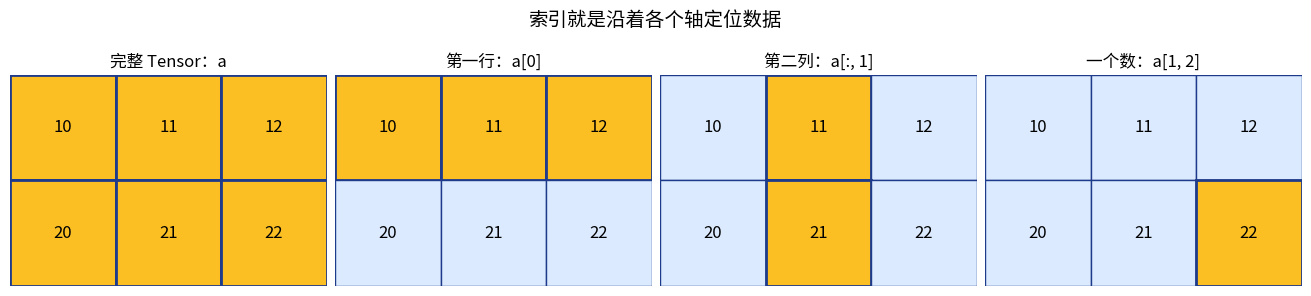

In [7]:
figure = plot_tensor_indexing(a)
plt.show()

## 4. 从一个样本到 mini-batch

在本项目的二维分类任务中，一个样本有两个特征：

\[
\mathbf{x}_i=[x_{i1},x_{i2}]
\]

它的形状是 `(2,)`。把多个样本按行叠起来，就得到一个 mini-batch：

\[
X_{\mathrm{batch}}\in\mathbb{R}^{B\times 2}
\]

其中 \(B\) 是一次送入模型的样本数，也就是 **batch size**。PyTorch 的 [Datasets & DataLoaders](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html) 正是用 DataLoader 将样本组织成批次。

一个样本 shape： torch.Size([2])
一批样本 shape： torch.Size([3, 2])


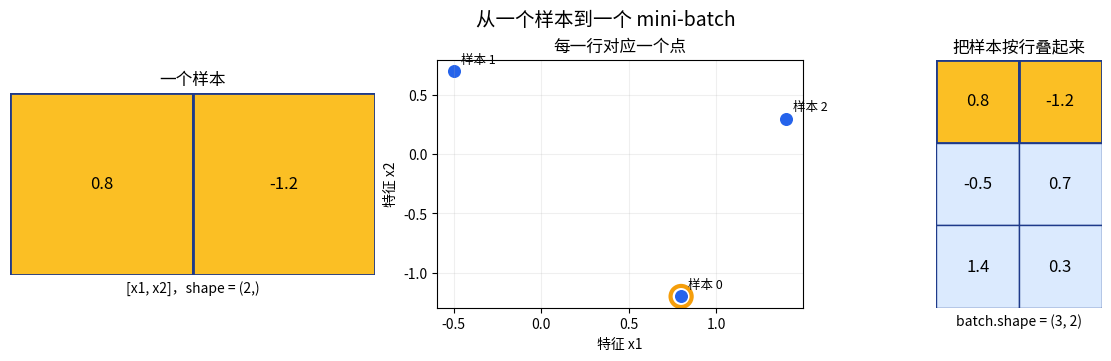

In [8]:
sample = torch.tensor([0.8, -1.2])
batch = torch.tensor([
    [0.8, -1.2],
    [-0.5, 0.7],
    [1.4, 0.3],
])

print("一个样本 shape：", sample.shape)
print("一批样本 shape：", batch.shape)

figure = plot_sample_to_batch(sample, batch)
plt.show()

### 4.1 先猜，再运行

假设 `batch.shape == (3, 2)`，请先猜下面三个结果的 shape：

1. `batch[0]`
2. `batch[:2]`
3. `batch[:, 0]`

In [9]:
answers = {
    "batch[0]": batch[0],
    "batch[:2]": batch[:2],
    "batch[:, 0]": batch[:, 0],
}

for expression, value in answers.items():
    print(f"{expression:12s} -> shape={tuple(value.shape)}，值={value.tolist()}")

batch[0]     -> shape=(2,)，值=[0.800000011920929, -1.2000000476837158]
batch[:2]    -> shape=(2, 2)，值=[[0.800000011920929, -1.2000000476837158], [-0.5, 0.699999988079071]]
batch[:, 0]  -> shape=(3,)，值=[0.800000011920929, -0.5, 1.399999976158142]


## 5. 为后面的手写数字和 CNN 搭桥

一张 28×28 的灰度图，本质上是 28 行、28 列像素值。

同一批图像送入不同模型时，常见形状是：

| 场景 | Tensor 形状 | 含义 |
|---|---:|---|
| 单张灰度图 | `[H, W]` | 28×28 个像素 |
| CNN 的单张输入 | `[C, H, W]` | 1 个灰度通道 |
| CNN 的一批输入 | `[B, C, H, W]` | B 张图同时输入 |
| MLP 的一批输入 | `[B, H×W]` | 每张图拉直为 784 个数 |

下面用几行代码画一个简化的“7”。这不是下载的数据集，只是为了看清形状如何变化。

[H, W]       = (28, 28)
[C, H, W]    = (1, 28, 28)
[B, C, H, W] = (4, 1, 28, 28)
[B, H×W]     = (4, 784)


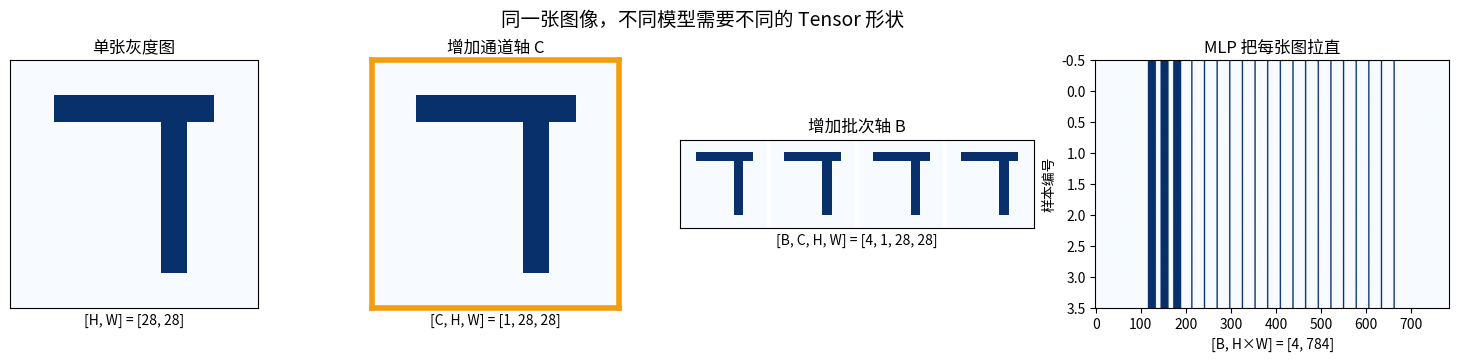

In [10]:
digit = torch.zeros(28, 28)
digit[4:7, 5:23] = 1.0
digit[7:24, 17:20] = 1.0

image_with_channel = digit.unsqueeze(0)
image_batch = image_with_channel.unsqueeze(0).repeat(4, 1, 1, 1)
mlp_batch = image_batch.reshape(4, -1)

print("[H, W]       =", tuple(digit.shape))
print("[C, H, W]    =", tuple(image_with_channel.shape))
print("[B, C, H, W] =", tuple(image_batch.shape))
print("[B, H×W]     =", tuple(mlp_batch.shape))

figure = plot_image_tensor_shapes(digit, batch_size=4)
plt.show()

这里有两个关键动作：

- `unsqueeze(0)`：在第 0 个位置增加一个长度为 1 的轴；
- `reshape(4, -1)`：保留 4 个样本，把每张图其余维度拉直；`-1` 由 PyTorch 自动计算为 784。

因此，图像的内容没有凭空改变，改变的是**组织方式**。

## 6. 回到本项目：moons 数据如何变成 Tensor

现在把前面的概念用于真正的二维分类数据。每个点有两个坐标，颜色表示类别。

为了后续训练，`make_dataset` 已经完成训练集/测试集划分，并且只使用训练集统计量进行标准化。这里先关注最终交给模型的 `x_train` 和 `y_train`。

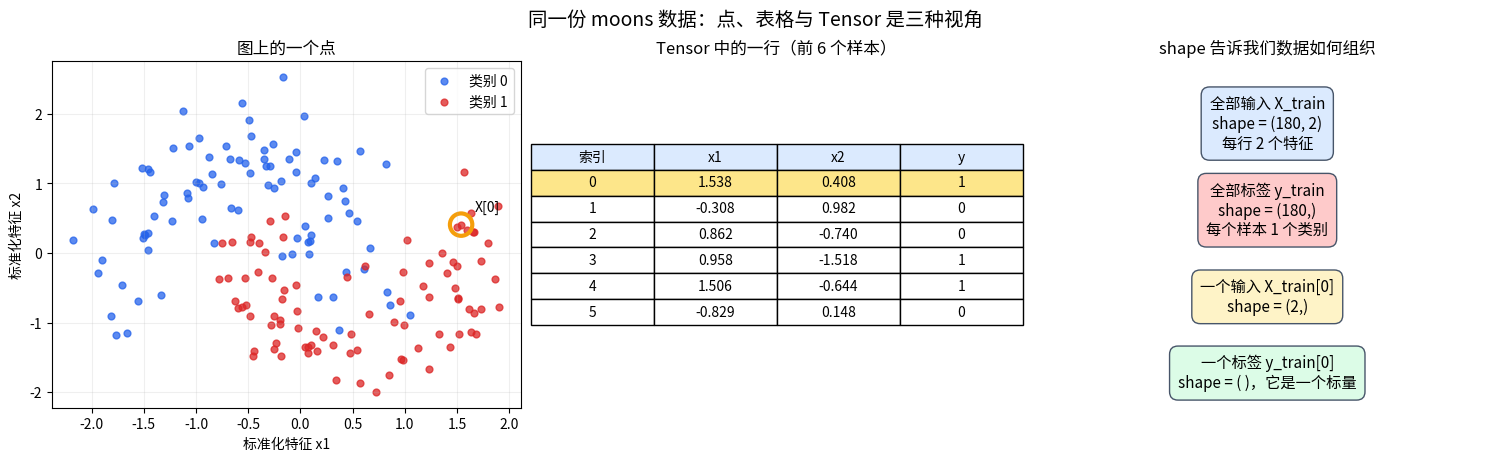

In [11]:
data = make_dataset("moons", n_samples=240, noise=0.22, seed=42)

figure = plot_moons_tensor_map(data)
plt.show()

In [12]:
print("x_train：", data.x_train.shape, data.x_train.dtype)
print("y_train：", data.y_train.shape, data.y_train.dtype)
print()

for index in range(3):
    print(
        f"样本 {index}: X[{index}]={data.x_train[index].tolist()}，"
        f"y[{index}]={data.y_train[index].item()}"
    )

x_train： torch.Size([180, 2]) torch.float32
y_train： torch.Size([180]) torch.int64

样本 0: X[0]=[1.5383409261703491, 0.40784722566604614]，y[0]=1
样本 1: X[1]=[-0.3081648051738739, 0.9818251132965088]，y[1]=0
样本 2: X[2]=[0.8618990778923035, -0.7403958439826965]，y[2]=0


### 6.1 用数学语言重新描述

含有 \(N\) 个样本、每个样本有 \(d=2\) 个特征的数据集可写为：

\[
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{N},
\qquad
\mathbf{x}_i=[x_{i1},x_{i2}]^\top
\]

把所有输入按行排列：

\[
X=
\begin{bmatrix}
x_{11} & x_{12}\\
x_{21} & x_{22}\\
\vdots & \vdots\\
x_{N1} & x_{N2}
\end{bmatrix}
\in\mathbb{R}^{N\times 2},
\qquad
\mathbf{y}=[y_1,y_2,\ldots,y_N]^\top
\]

代码中的 `data.x_train` 就是这个矩阵 \(X\)，`data.y_train` 就是标签向量 \(\mathbf y\)。

标准化使用：

\[
x'_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}
\]

它改变数值尺度，但不改变样本数、特征数和标签。

## 7. Tensor 进入 MLP 后，shape 如何变化

假设一次输入 8 个 moons 样本：

\[
[8,2]\rightarrow[8,16]\rightarrow[8,2]\rightarrow[8]
\]

- 第一个 `2`：每个点有两个输入特征；
- `16`：隐藏层为每个样本学习 16 个新特征；
- 第二个 `2`：两个类别各有一个分数（logit）；
- 最后的 `[8]`：8 个样本各得到一个预测类别。

批次大小 8 始终保留。

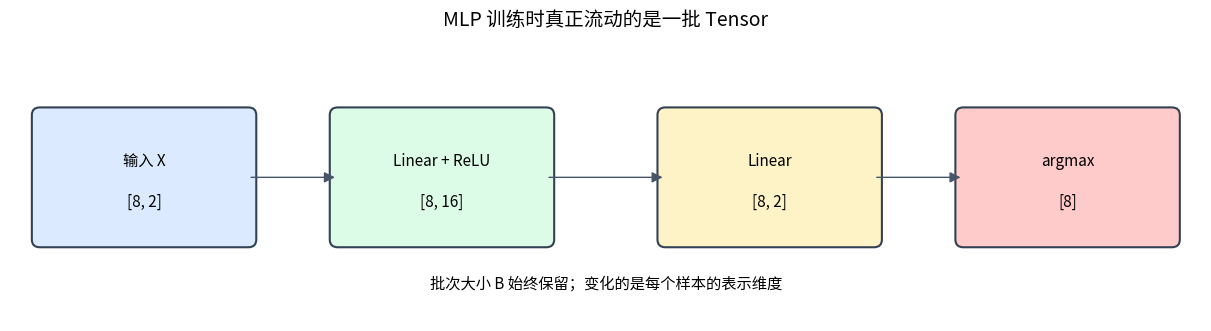

In [13]:
figure = plot_mlp_shape_flow(batch_size=8, hidden_size=16, n_classes=2)
plt.show()

### 7.1 最后一次 shape 检查

先在心里补全空格，再运行代码核对：

- 取 8 个样本：`mini_x.shape = (__, __)`
- 隐藏表示：`hidden.shape = (__, __)`
- 两类分数：`logits.shape = (__, __)`
- 预测类别：`prediction.shape = (__ ,)`

In [14]:
mini_x = data.x_train[:8]
hidden = torch.zeros(8, 16)
logits = torch.zeros(8, data.n_classes)
prediction = logits.argmax(dim=1)

for name, value in [
    ("mini_x", mini_x),
    ("hidden", hidden),
    ("logits", logits),
    ("prediction", prediction),
]:
    print(f"{name:10s}.shape = {tuple(value.shape)}")

assert mini_x.shape == (8, 2)
assert hidden.shape == (8, 16)
assert logits.shape == (8, 2)
assert prediction.shape == (8,)

mini_x    .shape = (8, 2)
hidden    .shape = (8, 16)
logits    .shape = (8, 2)
prediction.shape = (8,)


## 8. 本节小结

现在遇到 Tensor，可以按下面的顺序阅读：

1. **它代表什么对象？** 一个数、一个样本、一批样本，还是一批图像？
2. **shape 是什么？** 每个轴分别表示什么？
3. **dtype 是什么？** 特征通常是浮点数，分类标签通常是整数；
4. **device 在哪里？** CPU 或指定 GPU；
5. **索引后 shape 如何变化？** 取一个元素、一行或一个批次，结果不同。

请记住最重要的一句话：

> **Tensor 不是神秘的新数学对象，它是带有形状、类型和设备信息的多维数字容器。**

下一节将使用这些 Tensor 解释 batch size、epoch、学习率、损失函数和训练循环。

---

## 结束后释放资源

本 Notebook 没有使用 GPU，但结束时仍建议运行下一单元：它会关闭图片、清理变量并结束当前 Jupyter 内核。单元执行后显示“内核已停止”属于正常现象。

如果 VS Code 没有显示关闭按钮，也可以打开命令面板（`Ctrl+Shift+P`），执行 `Jupyter: Shut Down All Kernels`。

In [15]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch

plt.close("all")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("资源已释放，当前 Notebook 内核即将关闭。")
get_ipython().kernel.do_shutdown(restart=False)

资源已释放，当前 Notebook 内核即将关闭。


{'status': 'ok', 'restart': False}